#Setup

##SpaNotDom

In [ ]:
import pandas as pd

In [ ]:
lingFeatsOfInterest = ['file'] + ['# of words', 'Type Token Ratio', 'Noun to Verb ratio', 'Propositional Density','Open Closed Words Ratio',  'Average sentence length', 'Suboordination Main Verb Implied','Proportion Fillers' ,"Proportion Repetitions"]

In [ ]:
def simplifyID(id):
  return id.split('_')[0]

In [ ]:
spaNotDomLingDF = pd.read_csv('SPA_NotDom_LinguisticFeatures.csv')
spaNotDomLingDF.shape

(23, 239)

In [ ]:
spaNotDomLingDF = spaNotDomLingDF[lingFeatsOfInterest]
spaNotDomLingDF['file'] = spaNotDomLingDF['file'].apply(simplifyID)
#rename 'file' column to 'File' using .rename
spaNotDomLingDF.rename(columns={'file': 'File'}, inplace=True)
spaNotDomLingDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions
0,BILP007,84.0,0.559524,1.285714,0.416667,0.820000,9.333333,0.888889,0.076923,0.000000
1,BILP008,181.0,0.530387,1.250000,0.425414,0.771429,10.055556,0.777778,0.026882,0.000000
2,BILP010,97.0,0.608247,1.000000,0.391753,0.594203,5.705882,0.294118,0.118182,0.010309
3,BILP011,87.0,0.643678,1.818182,0.379310,0.666667,7.909091,0.545455,0.033333,0.000000
4,BILP012,97.0,0.567010,1.909091,0.309278,0.487179,5.705882,0.352941,0.155172,0.010309


In [ ]:
spaNotDomCLANDF = pd.read_csv('SPA_NotDOM_CLAN_Output.eval.csv')[['File','retracing']]
spaNotDomCLANDF['File'] = spaNotDomCLANDF['File'].apply(simplifyID)
spaNotDomCLANDF.head()

,File,retracing
0,BILP007,3
1,BILP008,5
2,BILP010,14
3,BILP011,7
4,BILP012,15


In [ ]:
spaNotDomFragmentDF = pd.read_csv('Spa_NotDom_Fragment.xls.csv')[['File','Token']]
spaNotDomFragmentDF['File'] = spaNotDomFragmentDF['File'].apply(simplifyID)
#rename token column to part-word repetition
spaNotDomFragmentDF.columns = ['File','part-word repetitions']
spaNotDomFragmentDF.head()

,File,part-word repetitions
0,BILP007,4
1,BILP008,1
2,BILP010,6
3,BILP011,2
4,BILP012,7


In [ ]:
#combine catDomLingDF, catDomCLANDF,catDomFragmentDF
spaNotDomDF = spaNotDomLingDF.merge(spaNotDomCLANDF, on='File').merge(spaNotDomFragmentDF, on='File')
#divide retracing, repetition and part-word repetition columns by '# of words' column
spaNotDomDF['retracing'] = spaNotDomDF['retracing'] / spaNotDomDF['# of words']
spaNotDomDF['part-word repetitions'] = spaNotDomDF['part-word repetitions'] / spaNotDomDF['# of words']
spaNotDomDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP007,84.0,0.559524,1.285714,0.416667,0.820000,9.333333,0.888889,0.076923,0.000000,0.035714,0.047619
1,BILP008,181.0,0.530387,1.250000,0.425414,0.771429,10.055556,0.777778,0.026882,0.000000,0.027624,0.005525
2,BILP010,97.0,0.608247,1.000000,0.391753,0.594203,5.705882,0.294118,0.118182,0.010309,0.144330,0.061856
3,BILP011,87.0,0.643678,1.818182,0.379310,0.666667,7.909091,0.545455,0.033333,0.000000,0.080460,0.022989
4,BILP012,97.0,0.567010,1.909091,0.309278,0.487179,5.705882,0.352941,0.155172,0.010309,0.154639,0.072165


In [ ]:
spaNotDomDF.shape

(23, 12)

##CatNotDom

In [ ]:
catNotDomLingDF = pd.read_csv('CAT_NotDom_LinguisticFeatures.csv')
catNotDomLingDF = catNotDomLingDF[lingFeatsOfInterest]
catNotDomLingDF['file'] = catNotDomLingDF['file'].apply(simplifyID)
#rename 'file' column to 'File' using .rename
catNotDomLingDF.rename(columns={'file': 'File'}, inplace=True)
print(catNotDomLingDF.shape)

(11, 10)


In [ ]:
catNotDomCLANDF = pd.read_csv('CAT_NotDOM_CLAN_Output.eval.csv')[['File','retracing']]
catNotDomCLANDF['File'] = catNotDomCLANDF['File'].apply(simplifyID)
catNotDomCLANDF = catNotDomCLANDF[catNotDomCLANDF['File'].isin(list(catNotDomLingDF['File']))]
print(catNotDomCLANDF.shape)

(11, 2)


In [ ]:
catNotDomFragmentDF = pd.read_csv('Cat_NotDom_Fragment.xls.csv', encoding='ISO-8859-1')[['File','Token']]
catNotDomFragmentDF['File'] = catNotDomFragmentDF['File'].apply(simplifyID)
#rename token column to part-word repetition
catNotDomFragmentDF.columns = ['File','part-word repetitions']
catNotDomFragmentDF = catNotDomFragmentDF[catNotDomFragmentDF['File'].isin(list(catNotDomLingDF['File']))]
#spaNotDomFragmentDF = spaNotDomFragmentDF[spaNotDomFragmentDF['File'].isin(list(catNonDomLingDF['File']))]
print(catNotDomFragmentDF.shape)

(11, 2)


In [ ]:
catNonDomDF = catNotDomLingDF.merge(catNotDomCLANDF, on='File').merge(catNotDomFragmentDF, on='File')
#divide retracing, repetition and part-word repetition columns by '# of words' column
catNonDomDF['retracing'] = catNonDomDF['retracing'] / catNonDomDF['# of words']
catNonDomDF['part-word repetitions'] = catNonDomDF['part-word repetitions'] / catNonDomDF['# of words']
catNonDomDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP006,206.0,0.432039,1.235294,0.417476,0.811966,7.103448,0.379310,0.024272,0.004854,0.053398,0.019417
1,BILP009,76.0,0.592105,1.066667,0.421053,0.744681,9.500000,0.625000,0.078947,0.000000,0.000000,0.000000
2,BILP013,260.0,0.453846,1.238095,0.438462,0.872340,8.965517,0.517241,0.015385,0.007692,0.030769,0.011538
3,BILP022,266.0,0.439850,0.977778,0.469925,0.785714,12.666667,1.190476,0.030075,0.003759,0.033835,0.067669
4,BILP024,180.0,0.544444,1.064516,0.433333,0.669492,10.000000,0.611111,0.083333,0.005556,0.077778,0.044444


In [ ]:
catNonDomDF.shape

(11, 12)

##Combine

In [ ]:
notDomLingDF = pd.concat([spaNotDomDF, catNonDomDF])
notDomLingDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP007,84.0,0.559524,1.285714,0.416667,0.820000,9.333333,0.888889,0.076923,0.000000,0.035714,0.047619
1,BILP008,181.0,0.530387,1.250000,0.425414,0.771429,10.055556,0.777778,0.026882,0.000000,0.027624,0.005525
2,BILP010,97.0,0.608247,1.000000,0.391753,0.594203,5.705882,0.294118,0.118182,0.010309,0.144330,0.061856
3,BILP011,87.0,0.643678,1.818182,0.379310,0.666667,7.909091,0.545455,0.033333,0.000000,0.080460,0.022989
4,BILP012,97.0,0.567010,1.909091,0.309278,0.487179,5.705882,0.352941,0.155172,0.010309,0.154639,0.072165


In [ ]:
notDomLingDF.shape

(34, 12)

In [ ]:
print(list(notDomLingDF['File']))

['BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019', 'BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018']


In [ ]:
data_X = notDomLingDF.drop(columns=['File'])
data_X.shape

(34, 11)

In [ ]:
def getClass(filename):
  if 'BISE' in filename:
    return 'nfv'
  if 'BILP' in filename:
    return 'lv'
  if 'BIOBS003' in filename or 'BIOBS005' in filename:
    return 'lv'
  if 'BIOBS004' in filename:
    return 'nfv'

In [ ]:
dataY = notDomLingDF['File'].apply(getClass)
dataY.shape

(34,)

In [ ]:
from collections import Counter
Counter(dataY)

Counter({'lv': 24, 'nfv': 10})

In [ ]:
data_Y = [0 if y == 'nfv' else 1 for y in dataY ]
print(data_Y)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

##Double-checking participant variant breakdown is correct

In [ ]:
primaryDemoDF = pd.read_csv('bilingual_WAB_lv_nfv_primary_sheet(Parent_Sheet).csv', encoding='ISO-8859-1')
primaryDemoDF.head()

,IDs,DomLang,"Catalan transcription copied to manuscripts folder 20240318 (13 non dom, 23 dom)",Age,variant,HSP/BC ID,Site,Comments,Recorded in,Logistics in recording,...,Pre-Tx_Date (DDMMYYY),Date_of_MRI,Link to folder for MRI,MRI uploaded to box,MRI Format,DOB (m/d/y),BACC_MRI_STATUS_20250320,path_hsp_cluster,closest_mri_cluster,Unnamed: 22
0,BILP006,Spanish,y,67,lv,1807086.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,9/2/2020,11/3/2020,MRI folder:,Y,.nii,4/25/1957,in-box,NaN,NaN,NaN
1,BILP007,Catalan,y,68,lv,70054820.0,BC,Not added in the analysis? why? Decided now to...,ZOOM .mp5,ZOOM recording (different laptops),...,12/28/2020,9/29/2020,NaN,Y,.rar,7/27/1956,BC,NaN,NaN,NaN
2,BILP008,Catalan,y,79,lv,525199.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,1/27/2021,2/16/2021,NaN,Y,.nii,6/2/1945,in-box,NaN,NaN,NaN
3,BILP009,Spanish,y,76,lv,80018295.0,BC,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,2/8/2021,1/19/2021,NaN,Y,.rar,7/3/1948,BC,NaN,NaN,NaN
4,BILP010,Catalan,y,82,lv,1741141.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,3/31/2021,11/16/2021 (no se presento),NaN,NaN,NaN,6/29/1942,Sí,/theshire/nicore/DATA/SPIN/sourcedata/1741141/...,20240113,NaN


In [ ]:
def simplifyVariant(variant):
  if 'nfv' in variant:
    return 'nfv'
  if 'lv' in variant:
    return 'lv'

In [ ]:
primaryDemoDF['variant'] =primaryDemoDF['variant'].apply(simplifyVariant)

In [ ]:
samples = list(notDomLingDF['File'])

In [ ]:
print(sorted(list(primaryDemoDF['IDs '])))
print(sorted(samples))

['BILP006', 'BILP007', 'BILP008', 'BILP009', 'BILP010', 'BILP011', 'BILP012', 'BILP013', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP022', 'BILP024', 'BILP025', 'BILP026', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']
['BILP006', 'BILP007', 'BILP008', 'BILP009', 'BILP010', 'BILP011', 'BILP012', 'BILP013', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP022', 'BILP024', 'BILP025', 'BILP026', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']


In [ ]:
assert sorted(list(primaryDemoDF['IDs '])) == sorted(samples)

In [ ]:
notDomLingDF['variant'] = notDomLingDF['File'].apply(getClass)
notDomLingDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions,variant
0,BILP007,84.0,0.559524,1.285714,0.416667,0.820000,9.333333,0.888889,0.076923,0.000000,0.035714,0.047619,lv
1,BILP008,181.0,0.530387,1.250000,0.425414,0.771429,10.055556,0.777778,0.026882,0.000000,0.027624,0.005525,lv
2,BILP010,97.0,0.608247,1.000000,0.391753,0.594203,5.705882,0.294118,0.118182,0.010309,0.144330,0.061856,lv
3,BILP011,87.0,0.643678,1.818182,0.379310,0.666667,7.909091,0.545455,0.033333,0.000000,0.080460,0.022989,lv
4,BILP012,97.0,0.567010,1.909091,0.309278,0.487179,5.705882,0.352941,0.155172,0.010309,0.154639,0.072165,lv


In [ ]:
print(sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'nfv']['IDs '])))
print(sorted(list(notDomLingDF[notDomLingDF['variant']=='nfv']['File'])))

['BIOBS004', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']
['BIOBS004', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']


In [ ]:
assert sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'nfv']['IDs '])) == sorted(list(notDomLingDF[notDomLingDF['variant']=='nfv']['File']))

In [ ]:
assert sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'lv']['IDs '])) == sorted(list(notDomLingDF[notDomLingDF['variant']=='lv']['File']))

In [ ]:
Counter(primaryDemoDF['variant'])

Counter({'lv': 24, 'nfv': 10})

#ML Methods

In [ ]:
print(data_Y)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


Extra functionalities: see predicted time needed, each fold's best model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
def looNCVWithTiming(param_grid, clf):
  import numpy as np
  import pandas as pd
  from sklearn.model_selection import GridSearchCV, LeaveOneOut
  from sklearn.inspection import permutation_importance
  from sklearn.metrics import accuracy_score
  from tqdm import tqdm
  import time
  from sklearn.model_selection import cross_val_predict
  from sklearn.metrics import confusion_matrix
  from sklearn.metrics import classification_report
  X = data_X
  y = np.array(data_Y)

# --- Storage ---
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()
  numInnerFolds = 5

  print("Running nested LOO CV")
  from sklearn.preprocessing import StandardScaler
  from sklearn.decomposition import PCA
  from sklearn.neural_network import MLPClassifier
  from sklearn.pipeline import Pipeline

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    start_time = time.time()
    #scaler = StandardScaler()
    grid_search = GridSearchCV(clf, param_grid, cv=numInnerFolds, scoring='f1_macro',n_jobs=-1) #n_jobs ensures parrallelization speedup
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"Best params for outer fold {test_idx}: {grid_search.best_params_}")

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1] #1 means P(aphasia)
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: cv loop lasted {elapsed:.2f} seconds")

# --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=['nfvPPA', 'lvPPA']))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)

  from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
  import numpy as np
  import matplotlib.pyplot as plt
  fpr, tpr, thresholds = roc_curve(data_Y, test_preds_probs)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc='lower right')
  plt.grid()
  plt.show()

# Post-Hoc Threshold Tuning
  optimal_idx = np.argmax(tpr - fpr)
  optimal_threshold = thresholds[optimal_idx]
  print(f"Optimal Threshold: {optimal_threshold}")

# Apply the optimal threshold
  adjusted_predictions = (test_preds_probs >= optimal_threshold).astype(int)
  print("Predictions using adjusted threshold:", adjusted_predictions)

# Evaluate the new predictions
  print("Confusion Matrix with Adjusted Threshold:")
  print(confusion_matrix(data_Y, adjusted_predictions))
  print("Classification Report with Adjusted Threshold:")
  print(classification_report(data_Y, adjusted_predictions, target_names=['nfvPPA', 'lvPPA']))

  print("Prettier confusion matrix for adjusted threshold:")
  generateBetterConfusionMatrix(test_true, adjusted_predictions)
  print("Prettier confusion matrix for default threshold:")
  generateBetterConfusionMatrix(test_true, test_preds)

In [ ]:
def generateBetterConfusionMatrix(test_true,test_preds):
  import matplotlib.pyplot as plt
  import numpy as np
  from sklearn.metrics import confusion_matrix

# Compute confusion matrix and normalized version
  cm = confusion_matrix(test_true, test_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  row_totals = cm.sum(axis=1)


  plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.labelsize': 16,     # x/y label size
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
  })


# Plot setup
  fig, ax = plt.subplots()
  im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)  # Use 'Blues'
  cbar = plt.colorbar(im, ax=ax)

# Axis setup
  class_names = ['nfvPPA', 'lvPPA']
  ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True diagnosis',
       xlabel='Predicted diagnosis')
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = row_totals[i]
        percent = cm_normalized[i, j] * 100

        # Get brightness to set text color (luminance rule of thumb)
        brightness = im.cmap(cm_normalized[i, j])[:3]  # RGB
        luminance = 0.299 * brightness[0] + 0.587 * brightness[1] + 0.114 * brightness[2]
        text_color = 'black' if luminance > 0.5 else 'white'

        ax.text(j, i, f'{percent:.0f}% ({count}/{total})',
                ha='center', va='center', color=text_color, fontsize=14)

  plt.tight_layout()
  plt.show()


#Stats tests

In [ ]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from matplotlib.pyplot import figure
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
temp_data_X = data_X.copy()
temp_data_X['Class'] = dataY
temp_data_X.head()

,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions,Class
0,84.0,0.559524,1.285714,0.416667,0.820000,9.333333,0.888889,0.076923,0.000000,0.035714,0.047619,lv
1,181.0,0.530387,1.250000,0.425414,0.771429,10.055556,0.777778,0.026882,0.000000,0.027624,0.005525,lv
2,97.0,0.608247,1.000000,0.391753,0.594203,5.705882,0.294118,0.118182,0.010309,0.144330,0.061856,lv
3,87.0,0.643678,1.818182,0.379310,0.666667,7.909091,0.545455,0.033333,0.000000,0.080460,0.022989,lv
4,97.0,0.567010,1.909091,0.309278,0.487179,5.705882,0.352941,0.155172,0.010309,0.154639,0.072165,lv


In [ ]:
lvDF = temp_data_X[temp_data_X['Class'] == 'lv']
nfvDF = temp_data_X[temp_data_X['Class'] == 'nfv']

In [ ]:
normallyDistributedFeats = []
notNormallyDistributedFeats = []
featurePValues = {}
for feature in data_X.columns:
  #use Shapiro-Wilk test to see if distribution of variables in both groups is normal
  if feature == 'Sample':
    continue
  _,p_nfv = stats.shapiro(nfvDF[feature])
  _,p_lv = stats.shapiro(lvDF[feature])
  # if both distribution are normal, use t-test
  if p_nfv > 0.05 and p_lv > 0.05:
    t_stat, p_feature = stats.ttest_ind(nfvDF[feature], lvDF[feature])
    featurePValues[feature] = float(p_feature)
    normallyDistributedFeats.append(feature)
  else: #if either distribution wasn't normal, use mannwhitney u test
    t_stat, p_feature = stats.mannwhitneyu(nfvDF[feature], lvDF[feature])
    featurePValues[feature] = float(p_feature)
    notNormallyDistributedFeats.append(feature)

In [ ]:
print(normallyDistributedFeats)

['Type Token Ratio', 'Propositional Density', 'Suboordination Main Verb Implied', 'retracing']


In [ ]:
print(notNormallyDistributedFeats)

['# of words', 'Noun to Verb ratio', 'Open Closed Words Ratio', 'Average sentence length', 'Proportion Fillers', 'Proportion Repetitions', 'part-word repetitions']


In [ ]:
print(featurePValues)

{'# of words': 0.003597684477221911, 'Type Token Ratio': 0.3904903666729861, 'Noun to Verb ratio': 0.014751225110550428, 'Propositional Density': 0.004881785531679911, 'Open Closed Words Ratio': 0.733710424619658, 'Average sentence length': 0.2812444192474246, 'Suboordination Main Verb Implied': 0.05168948922320414, 'Proportion Fillers': 0.8649236248138992, 'Proportion Repetitions': 0.7669037095551738, 'retracing': 0.02067206409775467, 'part-word repetitions': 0.6636892637178009}


In [ ]:
from statsmodels.stats.multitest import fdrcorrection

# 2. Apply FDR correction
all_features = list(featurePValues.keys())
raw_pvals = [featurePValues[feat] for feat in all_features]
rejected, fdr_corrected_pvals = fdrcorrection(raw_pvals)

# 3. Create corrected p-value dictionary
featureFDRPValues = dict(zip(all_features, fdr_corrected_pvals))


In [ ]:
print(featureFDRPValues)

{'# of words': np.float64(0.026849820424239508), 'Type Token Ratio': np.float64(0.6136277190575495), 'Noun to Verb ratio': np.float64(0.05408782540535157), 'Propositional Density': np.float64(0.026849820424239508), 'Open Closed Words Ratio': np.float64(0.8435940805106913), 'Average sentence length': np.float64(0.5156147686202784), 'Suboordination Main Verb Implied': np.float64(0.11371687629104911), 'Proportion Fillers': np.float64(0.8649236248138992), 'Proportion Repetitions': np.float64(0.8435940805106913), 'retracing': np.float64(0.05684817626882534), 'part-word repetitions': np.float64(0.8435940805106913)}


In [ ]:
featureFDRPValues.keys()

dict_keys(['# of words', 'Type Token Ratio', 'Noun to Verb ratio', 'Propositional Density', 'Open Closed Words Ratio', 'Average sentence length', 'Suboordination Main Verb Implied', 'Proportion Fillers', 'Proportion Repetitions', 'retracing', 'part-word repetitions'])

In [ ]:
featureFDRPValues['part-word repetitions']

np.float64(0.8435940805106913)

In [ ]:
featureFDRPValues['Proportion Repetitions']

np.float64(0.8435940805106913)

In [ ]:
#features with significant (i.e p<0.05)
significantFeatures = {k: v.item() for k, v in featureFDRPValues.items() if v < 0.05}
significantFeatures

{'# of words': 0.026849820424239508,
 'Propositional Density': 0.026849820424239508}

In [ ]:
import warnings

In [ ]:
def plotOneVariable(variable):
  sns.set_style(style='white')
  sns.set_palette("pastel")
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)  # suppress FutureWarnings (e.g., from seaborn)
    sns.violinplot(x='Class', y=variable, split=True, data=temp_data_X, palette=['#26457cff', '#eeeeeeff'],cut=0)
    sns.stripplot(x='Class', y=variable, data=temp_data_X, palette=['#26457cff', '#eeeeeeff'], size=3)
  plt.show()

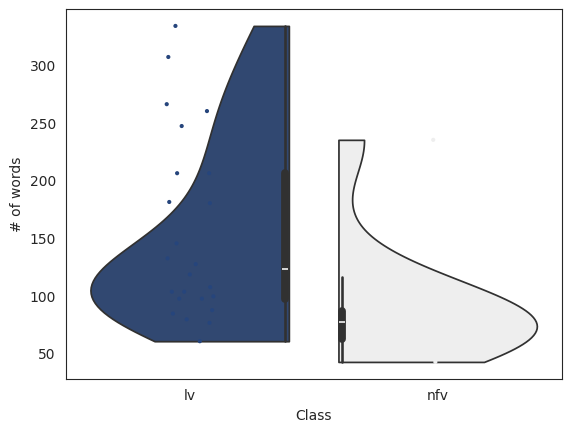

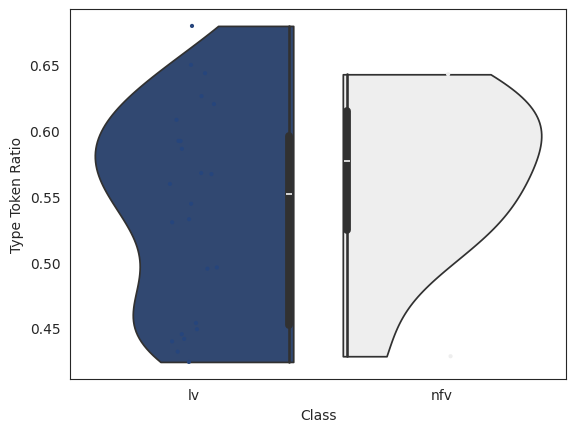

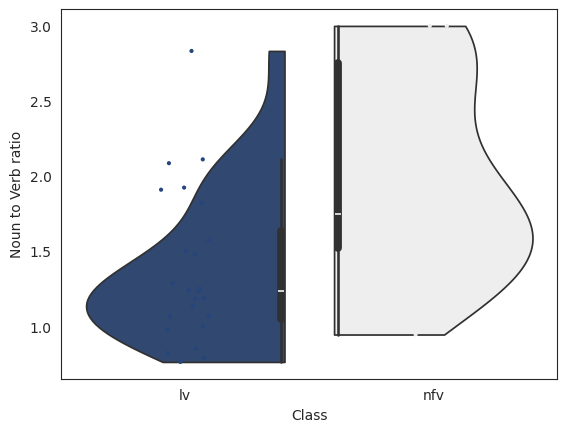

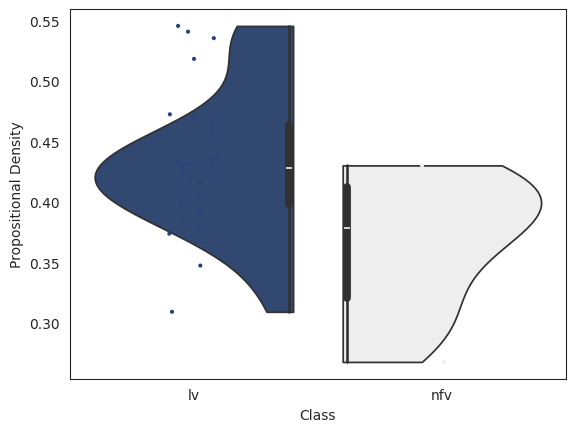

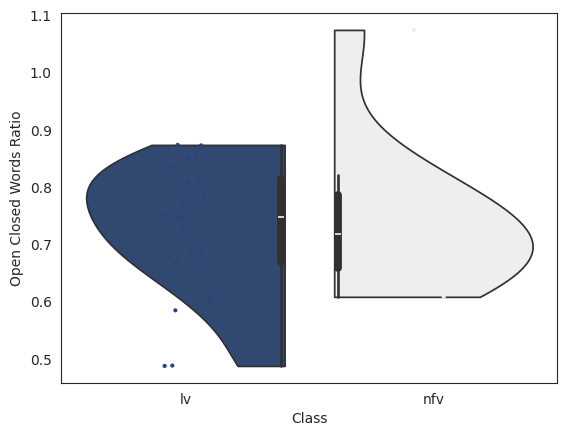

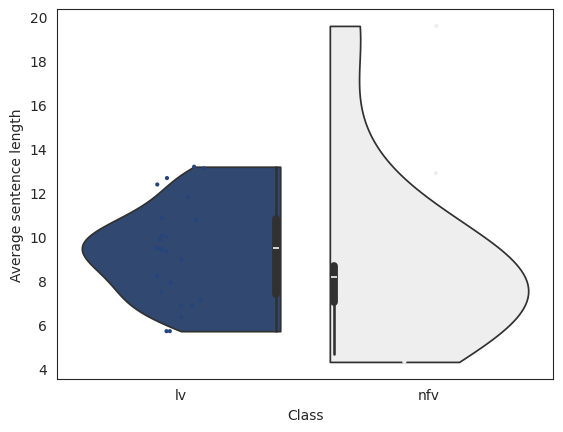

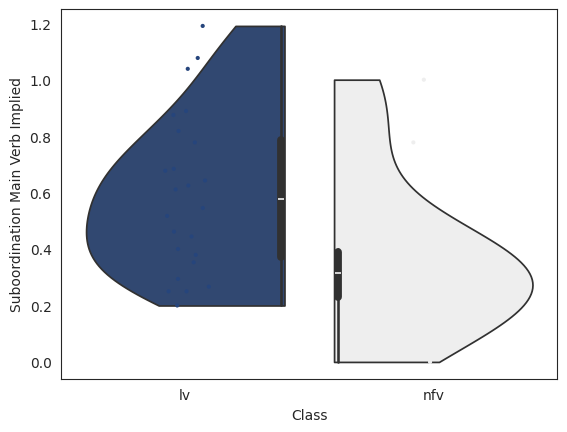

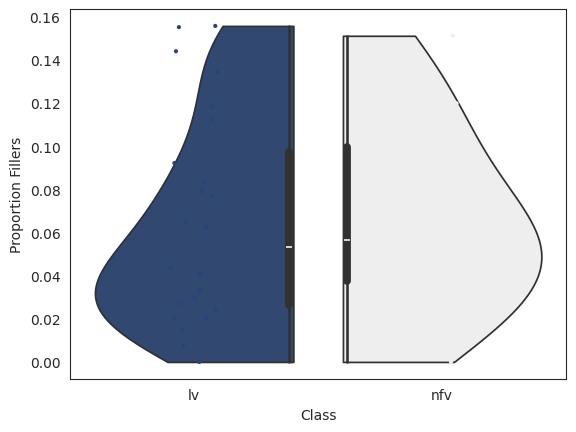

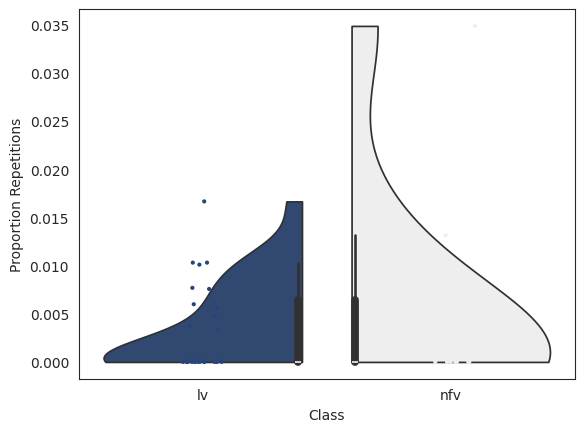

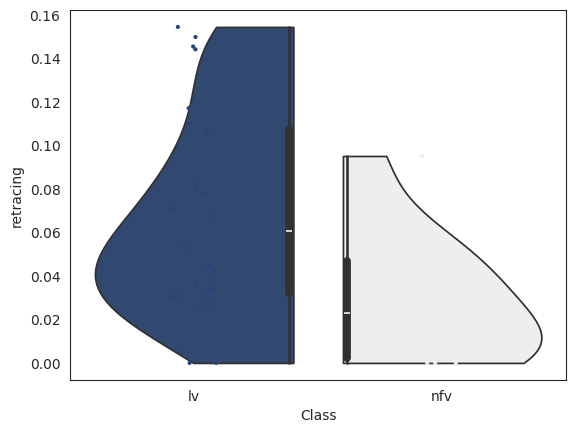

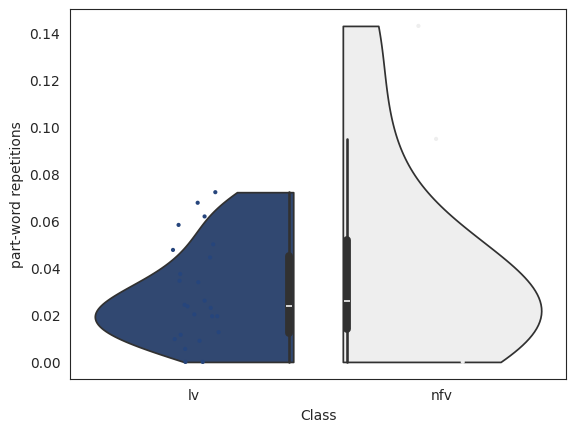

In [ ]:
for feature in temp_data_X.columns:
  if feature in ['Sample','Class']:
    continue
  plotOneVariable(feature)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

# suppress FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

def plot_multiple_violin_distributions_dots(df, feature_list, numPlotsPerRow=2):
    """
    Plots violin plots comparing the distribution of multiple features
    between two classes: 'nfv' (blue) and 'lv' (green),
    with individual data points shown as dots.

    Parameters:
    - df (pd.DataFrame): The dataframe containing the data.
    - feature_list (list of str): List of feature names to plot.
    """
    if 'Class' not in df.columns:
        raise ValueError("DataFrame must contain a 'Class' column.")

    # Filter out invalid features
    valid_features = [feat for feat in feature_list if feat in df.columns]
    invalid_features = [feat for feat in feature_list if feat not in df.columns]
    if invalid_features:
        print(f"Warning: These features were not found in the DataFrame and will be skipped: {invalid_features}")

    n = len(valid_features)
    if n == 0:
        raise ValueError("No valid features to plot.")

    class_order = ['nfv', 'lv']
    class_palette = {
        'nfv': 'purple',
        'lv': 'blue'
    }

    sns.set(style="whitegrid")

    # Determine layout
    cols = numPlotsPerRow
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    valid_features = [feat for feat in valid_features if feat not in ['Sample','Class']]


    for i, feature in enumerate(valid_features):
        ax = axes[i]

        # Violin plot
        sns.violinplot(
            data=df, x='Class', y=feature, ax=ax,
            order=class_order, palette=class_palette,
            inner="quartile", cut=0
        )

        # Add stripplot for datapoints
        sns.stripplot(
            data=df, x='Class', y=feature, ax=ax,
            order=class_order, dodge=True, color='black',
            alpha=0.6, size=4, jitter=True
        )
        ax.set_title(f'{feature}')
        ax.set_xlabel('Class')
        ax.set_ylabel('')

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


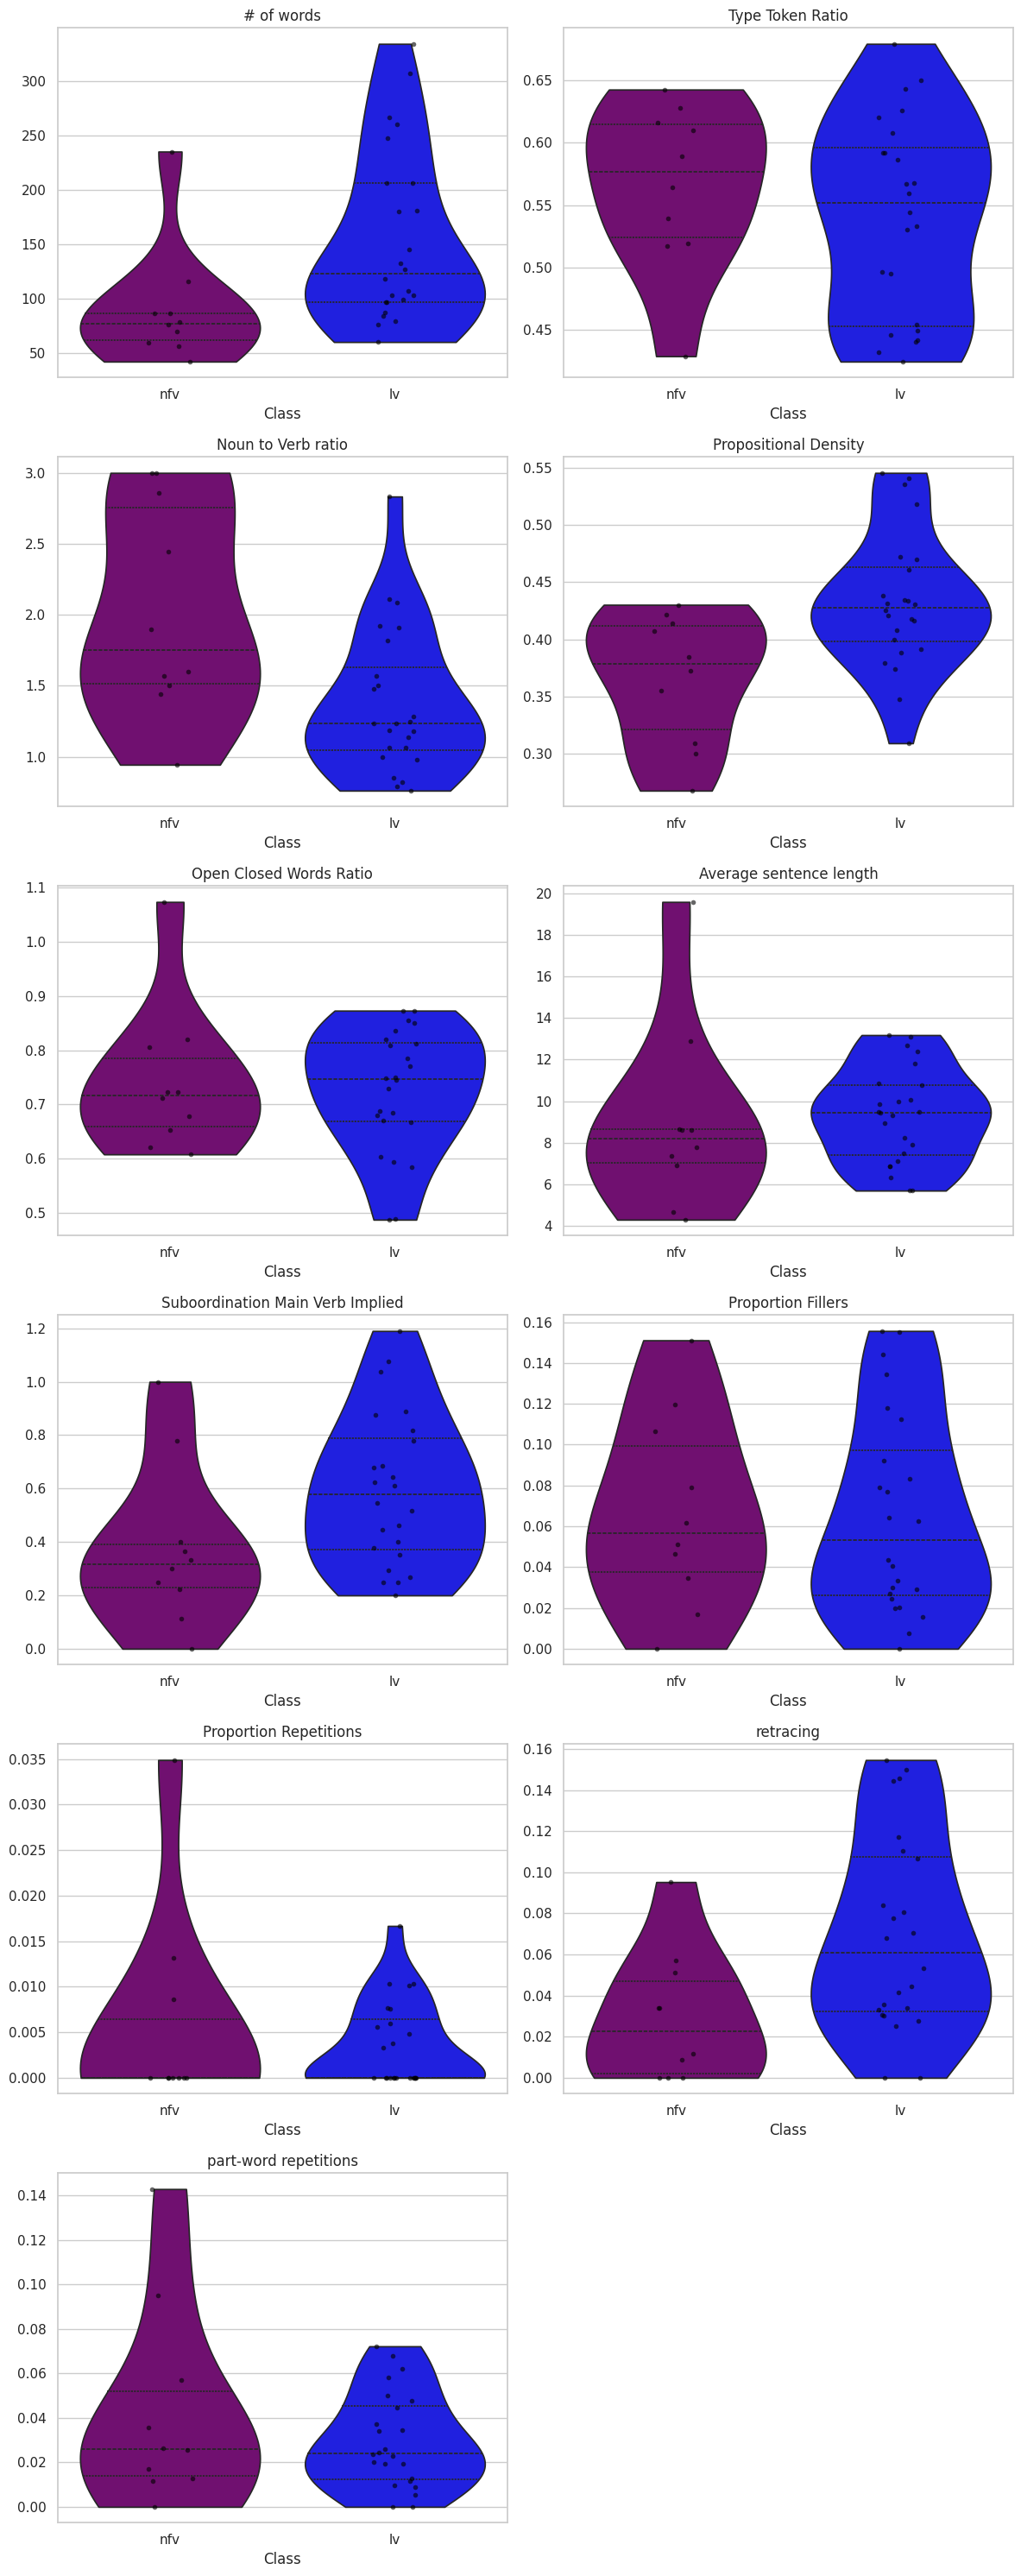

In [ ]:
plot_multiple_violin_distributions_dots(temp_data_X, temp_data_X.columns, numPlotsPerRow=2)

In [ ]:
import pandas as pd

# Example: assume your DataFrame is called df
means = temp_data_X.mean(numeric_only=True)
stds = temp_data_X.std(numeric_only=True)
mins = temp_data_X.min(numeric_only=True)
maxs = temp_data_X.max(numeric_only=True)

# Combine into a single summary table
summary = pd.DataFrame({
    'Mean': means,
    'Standard Deviation': stds,
    'Min': mins,
    'Max': maxs
})

print(summary)

                                        Mean  Standard Deviation        Min  \
# of words                        135.441176           77.877212  42.000000   
Type Token Ratio                    0.548025            0.075292   0.424242   
Noun to Verb ratio                  1.568619            0.649508   0.761905   
Propositional Density               0.413290            0.065382   0.267857   
Open Closed Words Ratio             0.729914            0.118704   0.487179   
Average sentence length             9.206767            3.006002   4.307692   
Suboordination Main Verb Implied    0.530179            0.300606   0.000000   
Proportion Fillers                  0.065777            0.047973   0.000000   
Proportion Repetitions              0.004198            0.007154   0.000000   
retracing                           0.057576            0.047057   0.000000   
part-word repetitions               0.033412            0.029859   0.000000   

                                         Max  
# of

In [ ]:
summary.to_csv('NDL_LingFeats.csv')

#Decision Tree (73%)

In [ ]:
decision_tree_param_grid = {
    "class_weight": ["balanced", None],
    "criterion": ["gini"],
    "max_depth": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:03<02:09,  3.91s/it]

Best params for outer fold [0]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}
Test idx 0: cv loop lasted 3.91 seconds


Outer folds:   6%|▌         | 2/34 [00:04<01:07,  2.10s/it]

Best params for outer fold [1]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}
Test idx 1: cv loop lasted 0.83 seconds


...

Best params for outer fold [31]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}
Test idx 31: cv loop lasted 0.53 seconds


Outer folds:  97%|█████████▋| 33/34 [00:22<00:00,  1.80it/s]

Best params for outer fold [32]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None}
Test idx 32: cv loop lasted 0.54 seconds


Outer folds: 100%|██████████| 34/34 [00:23<00:00,  1.45it/s]

Best params for outer fold [33]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None}
Test idx 33: cv loop lasted 0.51 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.58      0.70      0.64        10
       lvPPA       0.86      0.79      0.83        24

    accuracy                           0.76        34
   macro avg       0.72      0.75      0.73        34
weighted avg       0.78      0.76      0.77        34

Evaluation preds: [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]
Evaluation

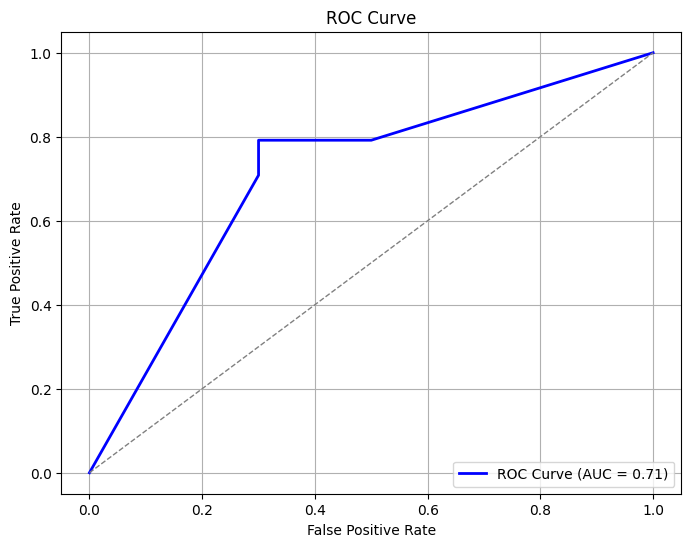

Optimal Threshold: 0.95
Predictions using adjusted threshold: [0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 7  3]
 [ 5 19]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.58      0.70      0.64        10
       lvPPA       0.86      0.79      0.83        24

    accuracy                           0.76        34
   macro avg       0.72      0.75      0.73        34
weighted avg       0.78      0.76      0.77        34

Prettier confusion matrix for adjusted threshold:


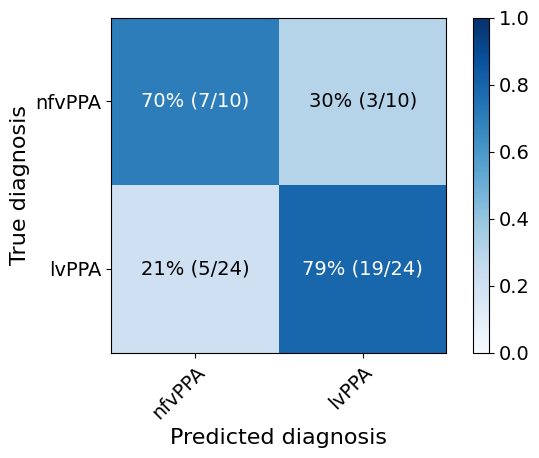

Prettier confusion matrix for default threshold:


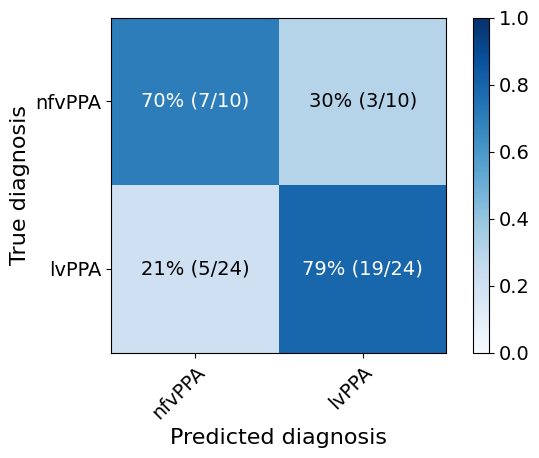

In [ ]:
looNCVWithTiming(param_grid=decision_tree_param_grid, clf=DecisionTreeClassifier(random_state=0))

#Gradient Boosting (69%)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:02<01:35,  2.91s/it]

Best params for outer fold [0]: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Test idx 0: cv loop lasted 2.90 seconds


Outer folds:   6%|▌         | 2/34 [00:06<01:43,  3.23s/it]

Best params for outer fold [1]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100}
Test idx 1: cv loop lasted 3.45 seconds


...

Best params for outer fold [31]: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50}
Test idx 31: cv loop lasted 4.09 seconds


Outer folds:  97%|█████████▋| 33/34 [01:46<00:03,  3.22s/it]

Best params for outer fold [32]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100}
Test idx 32: cv loop lasted 2.82 seconds


Outer folds: 100%|██████████| 34/34 [01:49<00:00,  3.21s/it]

Best params for outer fold [33]: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 100}
Test idx 33: cv loop lasted 2.86 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.40      0.44        10
       lvPPA       0.77      0.83      0.80        24

    accuracy                           0.71        34
   macro avg       0.63      0.62      0.62        34
weighted avg       0.69      0.71      0.70        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
Evaluation true: [np.int64(1), n

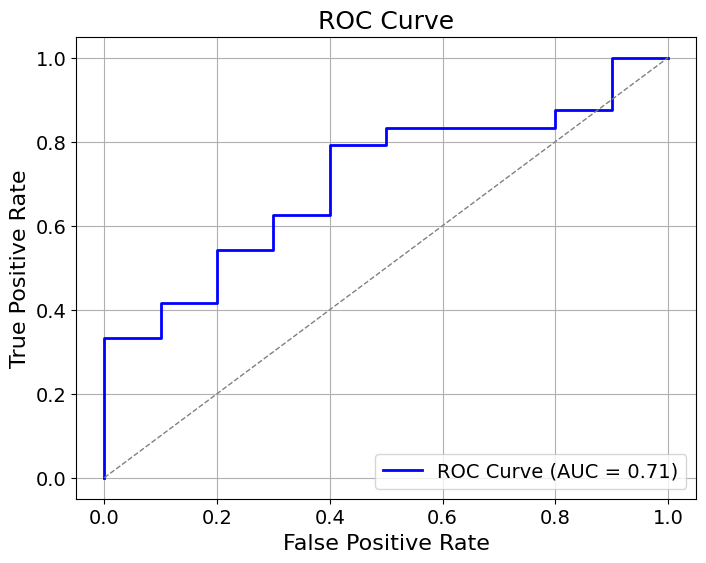

Optimal Threshold: 0.7812664822906807
Predictions using adjusted threshold: [1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 1 1 1 0 1 1 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 6  4]
 [ 5 19]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.55      0.60      0.57        10
       lvPPA       0.83      0.79      0.81        24

    accuracy                           0.74        34
   macro avg       0.69      0.70      0.69        34
weighted avg       0.74      0.74      0.74        34

Prettier confusion matrix for adjusted threshold:


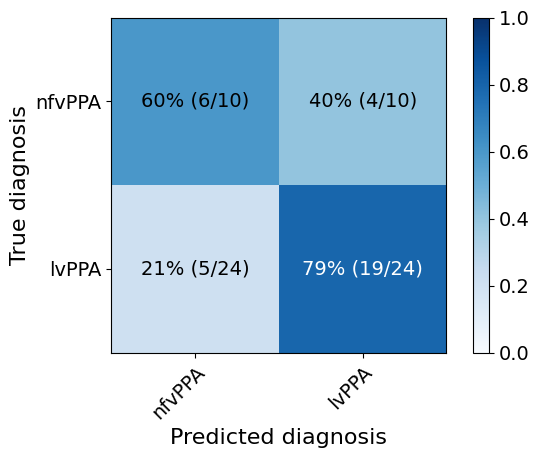

Prettier confusion matrix for default threshold:


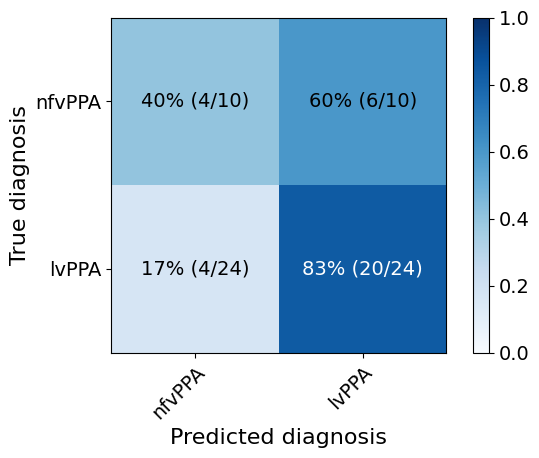

In [ ]:
gbcParamGrid = {
    "n_estimators": [25, 50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}
looNCVWithTiming(param_grid=gbcParamGrid, clf=GradientBoostingClassifier(random_state=0))

#SVM (50%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
reducer = PCA(random_state=0)
from sklearn.svm import SVC
clf = SVC(random_state=0,class_weight='balanced',probability=True)
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('pca', reducer), ('SVM', clf)])
linear_svm_grid = {
    "SVM__kernel": ["linear"],
    "SVM__C": [0.01, 0.1, 1.0],
    "SVM__class_weight": ["balanced", None]
}
rbf_svm_grid = {
    "pca__n_components": [1,2,3],
    "SVM__kernel": ["rbf"],
    "SVM__C": [0.1, 1.0],
    "SVM__gamma": ["scale"],
    "SVM__class_weight": ["balanced", None]
}
svmParamGrid = [linear_svm_grid, rbf_svm_grid]

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:00<00:28,  1.14it/s]

Best params for outer fold [0]: {'SVM__C': 0.1, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 0: cv loop lasted 0.87 seconds


Outer folds:   6%|▌         | 2/34 [00:01<00:27,  1.16it/s]

Best params for outer fold [1]: {'SVM__C': 0.1, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 1: cv loop lasted 0.85 seconds


...

Best params for outer fold [31]: {'SVM__C': 1.0, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 31: cv loop lasted 1.29 seconds


Outer folds:  97%|█████████▋| 33/34 [00:33<00:01,  1.07s/it]

Best params for outer fold [32]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 32: cv loop lasted 0.88 seconds


Outer folds: 100%|██████████| 34/34 [00:34<00:00,  1.02s/it]

Best params for outer fold [33]: {'SVM__C': 1.0, 'SVM__class_weight': None, 'SVM__kernel': 'linear'}
Test idx 33: cv loop lasted 0.90 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.30      0.38        10
       lvPPA       0.75      0.88      0.81        24

    accuracy                           0.71        34
   macro avg       0.62      0.59      0.59        34
weighted avg       0.68      0.71      0.68        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
Evaluation true: [np.int

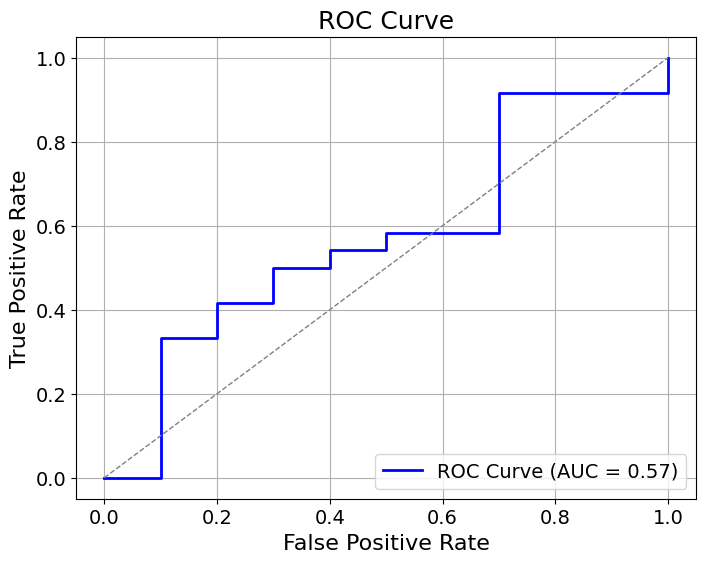

Optimal Threshold: 0.748722337235081
Predictions using adjusted threshold: [0 1 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 9  1]
 [16  8]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.36      0.90      0.51        10
       lvPPA       0.89      0.33      0.48        24

    accuracy                           0.50        34
   macro avg       0.62      0.62      0.50        34
weighted avg       0.73      0.50      0.49        34

Prettier confusion matrix for adjusted threshold:


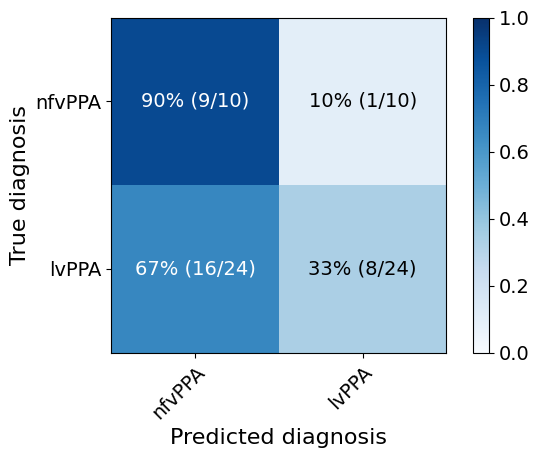

Prettier confusion matrix for default threshold:


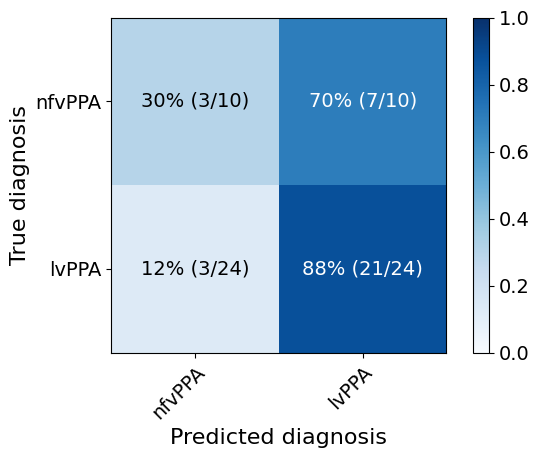

In [ ]:
looNCVWithTiming(param_grid=svmParamGrid, clf=pipe)

#Shallow Neural Net (23%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    random_state=0,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10
)

In [ ]:
snn_param_grid = {
    "MLP__hidden_layer_sizes": [
        (5,), #minimal nonlinearity
        (10,), #moderate flexibility
        (15,) #Hidden units ≲ number of features
    ],
    "MLP__activation": [
        "tanh", #Zero-centered, stable for small datasets
        "relu" #default activation function
    ],
    "MLP__alpha": [
        1e-4,
        1e-3,
        1e-2
    ],
    "MLP__solver": [
        "adam"
    ]
}


Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:01<00:54,  1.64s/it]

Best params for outer fold [0]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (10,), 'MLP__solver': 'adam'}
Test idx 0: cv loop lasted 1.64 seconds


Outer folds:   6%|▌         | 2/34 [00:03<00:51,  1.62s/it]

Best params for outer fold [1]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (10,), 'MLP__solver': 'adam'}
Test idx 1: cv loop lasted 1.61 seconds


...

Best params for outer fold [31]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (10,), 'MLP__solver': 'adam'}
Test idx 31: cv loop lasted 1.75 seconds


Outer folds:  97%|█████████▋| 33/34 [01:01<00:01,  1.78s/it]

Best params for outer fold [32]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 32: cv loop lasted 1.69 seconds


Outer folds: 100%|██████████| 34/34 [01:03<00:00,  1.88s/it]

Best params for outer fold [33]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 33: cv loop lasted 2.76 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.26      0.50      0.34        10
       lvPPA       0.67      0.42      0.51        24

    accuracy                           0.44        34
   macro avg       0.46      0.46      0.43        34
weighted avg       0.55      0.44      0.46        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1),

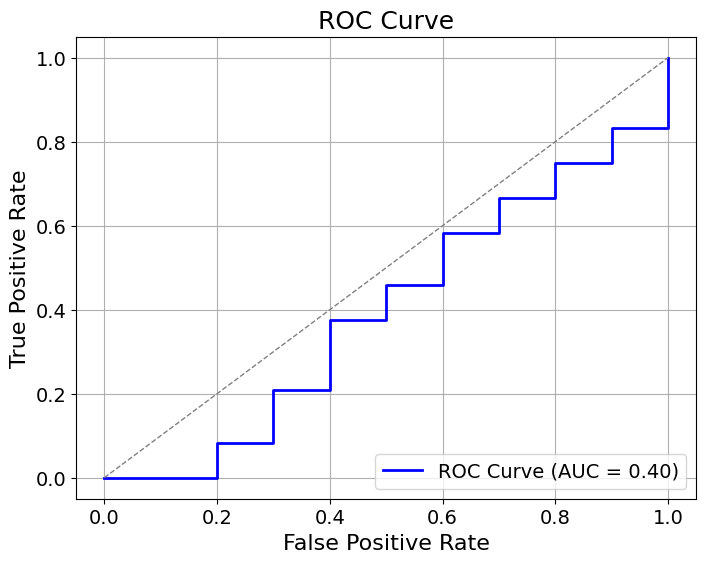

Optimal Threshold: inf
Predictions using adjusted threshold: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Confusion Matrix with Adjusted Threshold:
[[10  0]
 [24  0]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.29      1.00      0.45        10
       lvPPA       0.00      0.00      0.00        24

    accuracy                           0.29        34
   macro avg       0.15      0.50      0.23        34
weighted avg       0.09      0.29      0.13        34

Prettier confusion matrix for adjusted threshold:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


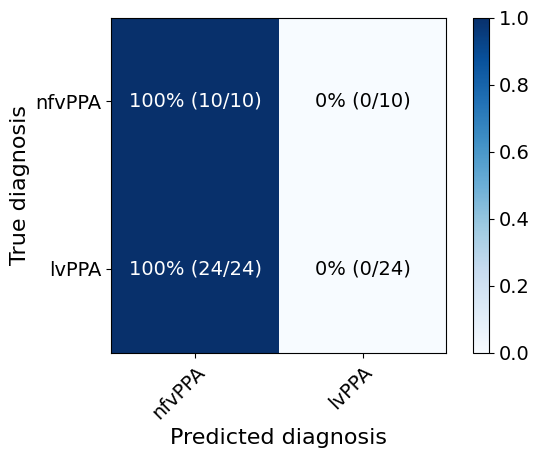

Prettier confusion matrix for default threshold:


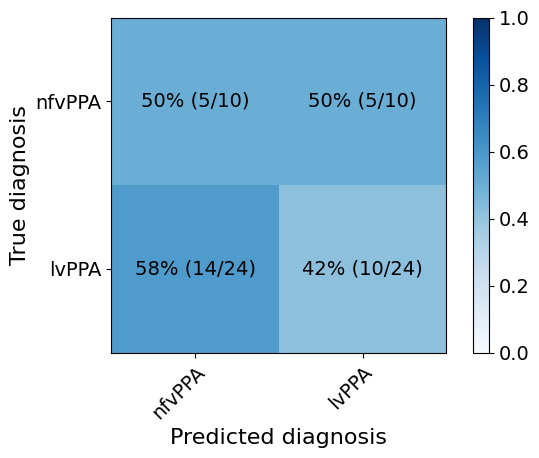

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('MLP', clf)])
looNCVWithTiming(param_grid=snn_param_grid, clf=pipe)

#Most Freq Baseline (41%)



In [ ]:
#import DummyClassifier from sklearn
from sklearn.dummy import DummyClassifier
#import cross_val_predict from sklearn
from sklearn.model_selection import cross_val_predict

In [ ]:
mostfreq_baseline = DummyClassifier(strategy="most_frequent",random_state=99)
predicted = cross_val_predict(mostfreq_baseline, data_X, data_Y, cv=5)
print(predicted)
print(confusion_matrix(data_Y, predicted))
print(classification_report(data_Y, predicted,target_names=['Non-Aphasia','Aphasia']))
print(accuracy_score(data_Y, predicted))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 0 10]
 [ 0 24]]
              precision    recall  f1-score   support

 Non-Aphasia       0.00      0.00      0.00        10
     Aphasia       0.71      1.00      0.83        24

    accuracy                           0.71        34
   macro avg       0.35      0.50      0.41        34
weighted avg       0.50      0.71      0.58        34

0.7058823529411765


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Permutation analysis

##General code

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time


def looNCVPermutationImportance(clf, param_grid, threshold, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA']):
  X = data_X
  y = np.array(data_Y)
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()

  print("Running nested LOO CV with permutation importance...")

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    #print(train_idx, test_idx)
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    gridSearch = GridSearchCV(clf, param_grid, cv=5, scoring=criterion)
    gridSearch.fit(X_train, y_train)
    best_model = gridSearch.best_estimator_

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)

    # Permutation importance (with timing)
    start_time = time.time()
    result = permutation_importance(
        best_model,
        X_train,
        y_train,
        n_repeats=n_repeats,
        random_state=42,
        scoring=criterion,
        n_jobs=-1
    )
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: Permutation importance took {elapsed:.2f} seconds")

    perm_importances_per_fold.append(result.importances_mean)

# --- Aggregate permutation importances ---
  perm_importances_per_fold = np.array(perm_importances_per_fold)
  feature_names = X.columns
  mean_importances = np.mean(perm_importances_per_fold, axis=0)
  median_importances = np.median(perm_importances_per_fold, axis=0)

# --- Report ---
  importances_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importances,
    'median_importance': median_importances
  }).sort_values(by='mean_importance', ascending=False)

  print("\nPermutation Importances Across LOO CV:")
  #print(importances_df)

  # --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=class_names))

  print("Mean feature importance:", list(zip(importances_df['feature'], importances_df['mean_importance'])))
  print("Median feature importance:", list(zip(importances_df['feature'], importances_df['median_importance'])))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)
  print("Tuned threshold:", threshold)
  adjusted_test_preds = [1 if x >= threshold else 0 for x in test_preds_probs]
  print("Evaluation preds with tuned threshold:", adjusted_test_preds)
  print("Classification Report with tuned Threshold:")
  print(classification_report(test_true, adjusted_test_preds, target_names=class_names))
  #return importances_df

##run

In [ ]:
decision_tree_param_grid = {
    "class_weight": ["balanced", None],
    "criterion": ["gini"],
    "max_depth": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

In [ ]:
looNCVPermutationImportance(clf=DecisionTreeClassifier(random_state=0), param_grid=decision_tree_param_grid, threshold=0.95, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA'])

Running nested LOO CV with permutation importance...


Outer folds:   3%|▎         | 1/34 [06:02<3:19:06, 362.03s/it]

Test idx 0: Permutation importance took 361.13 seconds


Outer folds:   6%|▌         | 2/34 [11:55<3:10:27, 357.11s/it]

Test idx 1: Permutation importance took 353.04 seconds


...

Test idx 31: Permutation importance took 354.65 seconds


Outer folds:  97%|█████████▋| 33/34 [3:14:43<05:51, 351.82s/it]

Test idx 32: Permutation importance took 347.35 seconds


Outer folds: 100%|██████████| 34/34 [3:20:39<00:00, 354.09s/it]

Test idx 33: Permutation importance took 354.83 seconds

Permutation Importances Across LOO CV:
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.58      0.70      0.64        10
       lvPPA       0.86      0.79      0.83        24

    accuracy                           0.76        34
   macro avg       0.72      0.75      0.73        34
weighted avg       0.78      0.76      0.77        34

Mean feature importance: [('# of words', 0.32795972886786934), ('Average sentence length', 0.13852171483312023), ('Propositional Density', 0.12165579576922217), ('Noun to Verb ratio', 0.037929084748176134), ('retracing', 0.028018440932037616), ('Proportion Repetitions', 0.02615234302876593), ('part-word repetitions', 0.01406573124737652), ('Proportion Fillers', 0.003916483026814659), ('Open Closed Words Ratio', 0.00343991774857537), ('Type Token Ratio', 0.0), ('Suboordination Main Verb Implied', 0.0)]
Median feature importanc